Train batches: 338 | Val: 43 | Test: 43
  AnnualCrop             2400
  Forest                 2400
  HerbaceousVegetation   2400
  Highway                2000
  Industrial             2000
  Pasture                1600
  PermanentCrop          2000
  Residential            2400
  River                  2000
  SeaLake                2400


/Users/sanjanachecker/csc/csc587/csc587_finalproj/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


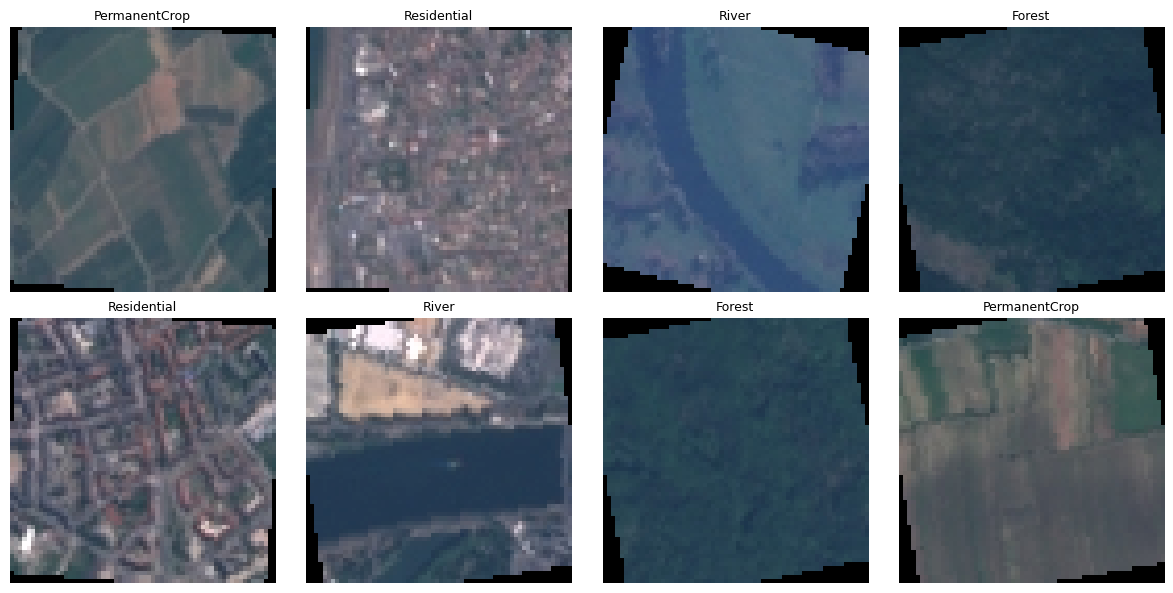

In [1]:
import sys, collections
sys.path.append("../src")

from dataset import get_dataloaders, CLASSES
import matplotlib.pyplot as plt
import torch

train_loader, val_loader, test_loader = get_dataloaders(
    processed_dir="../data/processed",
    data_root="../data/raw",
    batch_size=64,
    num_workers=0,
)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

# Class balance check on the training split
counts = collections.Counter()
for _, y in train_loader.dataset.samples:
    counts[CLASSES[y]] += 1
for cls, c in sorted(counts.items()):
    print(f"  {cls:<22s} {c}")

# Visualize a batch (denormalize for display)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, lbl in zip(axes.flat, imgs[:8], labels[:8]):
    ax.imshow((img * std + mean).clamp(0,1).permute(1,2,0))
    ax.set_title(CLASSES[lbl.item()], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()